[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase1_memory_architectures/02_long_term_memory.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 1B - Long-term memory (06-11)

**Phase 1B - Long-term memory (06-11)** - an independent notebook (runnable standalone in Colab or locally).

Covers: Long-term memory (06-11) - persist across sessions.

Attribution: adapted from *Agent Memory Techniques* by Nir Diamant (https://github.com/NirDiamant/Agent_Memory_Techniques), Apache-2.0. Inline demos are original.

## 0. Setup (self-contained - run this first)

In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

from embedder import TfidfHashEmbedder
from llm_client import LLMConfig, make_client, OfflineLLMClient
from memory_core import MemoryRecord
from providers import build_provider
emb = TfidfHashEmbedder()
TURNS = [
 ("Alice", "Hi, I am Alice. I work as a data scientist at a health-tech startup in Berlin."),
 ("Bob", "I am Bob, an ML engineer in Athens. I prefer PyTorch."),
 ("Alice", "We deploy on Kubernetes and track runs with Weights and Biases."),
 ("Bob", "Our training run failed last night with CUDA OOM at batch 256."),
 ("Alice", "We hit that before. Reducing batch to 64 and enabling gradient checkpointing fixed it."),
 ("Bob", "Our best val_loss was 0.423 with lr=3e-4 and weight_decay=0.01."),
 ("Alice", "I live in Prenzlauer Berg. My favorite coffee shop is on Kollwitzplatz."),
 ("Bob", "Let us sync next Tuesday at 10am CET."),
]
records = [MemoryRecord(f"t{i}", f"{w}: {t}", {"session_id": "s1" if i < 4 else "s2"}) for i, (w, t) in enumerate(TURNS)]
print("setup OK | turns =", len(TURNS))


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab / local file) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


## Long-term memory (06-11) - persist across sessions

**06 - Vector Store** · Embed turns; retrieve by similarity

In [3]:
# Technique 06 - Vector Store: Embed turns; retrieve by similarity
p=build_provider('verbatim',emb,llm); p.ingest(records); it,_=p.retrieve('What is Alices job?',3)
print('06 vector top:', (it[0].content[:40] if it else None))

06 vector top: Alice: I live in Prenzlauer Berg. My fav


**07 - Entity Memory** · Track facts about people/things

In [4]:
# Technique 07 - Entity Memory: Track facts about people/things
try:
 _facts = llm.extract_facts(chr(10).join(f'{w}: {t}' for w,t in TURNS[:5]))
 print('07 entities/facts (LLM):', _facts[:3])
except Exception:
 import re
 _ents = {n: ' '.join(t for _,t in TURNS if n in t)[:40] for n in ['Alice','Bob']}
 print('07 entities (offline):', _ents)

07 entities/facts (LLM): ['Alice is named Alice.', 'Alice works as a data scientist.', 'Alice works at a health-tech startup.']


**08 - Knowledge Graph** · Triples of how entities connect

In [5]:
# Technique 08 - Knowledge Graph: Triples of how entities connect
triples=[('Alice','works_in','Berlin'),('Bob','role','ML engineer'),('run','failed_with','OOM')]
print('08 KG triples:', triples)

08 KG triples: [('Alice', 'works_in', 'Berlin'), ('Bob', 'role', 'ML engineer'), ('run', 'failed_with', 'OOM')]


**09 - Episodic Memory** · Store whole interactions + when/where

In [6]:
# Technique 09 - Episodic Memory: Store whole interactions + when/where
p=build_provider('episodic',emb,llm); p.ingest(records); print('09 episodic episodes:', p.size())

09 episodic episodes: 2


**10 - Semantic Memory** · Extract general facts, dedup/resolve

In [7]:
# Technique 10 - Semantic Memory: Extract general facts, dedup/resolve
p=build_provider('extracted_facts',emb,llm); p.ingest(records); print('10 semantic facts:', p.size())

10 semantic facts: 23


**11 - Procedural Memory** · Capture how-to knowledge

In [8]:
# Technique 11 - Procedural Memory: Capture how-to knowledge
procs=['if OOM: batch 64 + gradient checkpointing','track runs with W&B']
print('11 procedural how-to:', procs[0])

11 procedural how-to: if OOM: batch 64 + gradient checkpointing


### 📊 Visualize — long-term footprint + what each store remembers

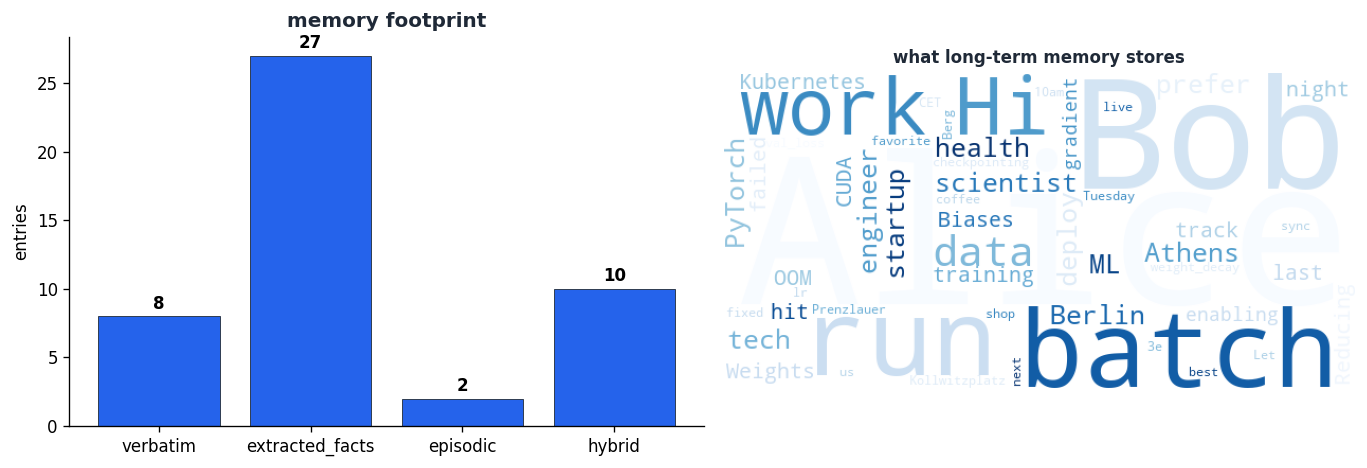

In [9]:
import matplotlib.pyplot as plt, subprocess, sys
from collections import Counter
names=["verbatim","extracted_facts","episodic","hybrid"]; sizes=[]
for n in names:
    p=build_provider(n,emb,llm); p.ingest(records); sizes.append(p.size())
text=" ".join(f"{w} {t}" for w,t in TURNS)
fig,ax=plt.subplots(1,2,figsize=(11.5,4),dpi=120)
ax[0].bar(names,sizes,color="#2563EB",edgecolor="#1F2937",linewidth=0.5)
for i,v in enumerate(sizes): ax[0].text(i,v+max(sizes)*0.02,str(v),ha="center",weight="bold")
ax[0].set_title("memory footprint",color="#1F2937",weight="bold"); ax[0].set_ylabel("entries")
ax[0].spines[["top","right"]].set_visible(False)
def _wc(text, ax):
    try:
        from wordcloud import WordCloud
    except Exception:
        subprocess.run([sys.executable,"-m","pip","install","-q","wordcloud"],check=False,timeout=180)
        try: from wordcloud import WordCloud
        except Exception: WordCloud=None
    if WordCloud:
        ax.imshow(WordCloud(width=600,height=300,background_color="white",colormap="Blues").generate(text)); ax.set_axis_off()
    else:
        c=Counter(text.lower().split()).most_common(8)
        ax.bar([w for w,_ in c],[v for _,v in c],color="#15803D")
_wc(text, ax[1]); ax[1].set_title("what long-term memory stores",color="#1F2937",weight="bold",fontsize=10)
fig.tight_layout(); plt.show()